# Baseline Models

This notebook establishes baseline performance using chronological data splits:

- Training: FY2010–2017
- Validation: FY2018
- Final test set: FY2019, held untouched

Models are compared primarily with PR-AUC because charged-off loans are the minority class. The FY2019 test set will not be used in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
FEATURES_PATH = "../data/processed/sba_7a_features.csv"
TARGET_COL = "default"

TRAIN_END_YEAR = 2017
VALIDATION_YEAR = 2018
TEST_YEAR = 2019

## Load feature dataset and recreate the temporal split

The feature dataset contains deterministic transformations only. Imputation, scaling, and one-hot encoding are fit using training data only.

In [2]:
df = pd.read_csv(
    FEATURES_PATH,
    dtype={
        "naics_sector": "string",
        "CongressionalDistrict": "string",
        "approval_month": "string",
    },
    low_memory=False,
)

train_df = df.loc[df["ApprovalFY"] <= TRAIN_END_YEAR].copy()
validation_df = df.loc[df["ApprovalFY"] == VALIDATION_YEAR].copy()
test_df = df.loc[df["ApprovalFY"] == TEST_YEAR].copy()

assert len(train_df) + len(validation_df) + len(test_df) == len(df)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_validation = validation_df.drop(columns=[TARGET_COL])
y_validation = validation_df[TARGET_COL]

print(f"Training loans: {len(X_train):,} | default rate: {y_train.mean():.2%}")
print(
    f"Validation loans: {len(X_validation):,} | "
    f"default rate: {y_validation.mean():.2%}"
)
print(f"Held-out FY2019 test loans: {len(test_df):,}")

Training loans: 355,031 | default rate: 7.55%
Validation loans: 42,237 | default rate: 10.13%
Held-out FY2019 test loans: 31,606


## Preprocessing pipeline

Numeric variables use median imputation, missing-value indicators, and scaling. Categorical variables use most-frequent-value imputation and one-hot encoding.

The resulting pipeline prevents validation data from influencing preprocessing.

In [3]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['ApprovalFY', 'InitialInterestRate', 'JobsSupported', 'sba_guarantee_ratio', 'is_franchise', 'sold_secondary_market', 'log_gross_approval', 'log_sba_guaranteed_approval', 'term_years', 'same_state_lender']
Categorical features: ['BankState', 'ProcessingMethod', 'FixedorVariableInterestInd', 'ProjectState', 'SBADistrictOffice', 'CongressionalDistrict', 'BusinessType', 'RevolverStatus', 'CollateralInd', 'naics_sector', 'approval_month', 'guarantee_ratio_bucket', 'business_age_group']


In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True,
    )),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

## Models

Three baseline models are compared:

1. A dummy classifier, showing why accuracy is misleading for this imbalanced dataset.
2. Regularized logistic regression.
3. Logistic regression with balanced class weights.

Class weighting is tested instead of SMOTE because it is simpler, preserves the chronological training distribution, and is easier to explain.

In [5]:
models = {
    "Dummy classifier": DummyClassifier(
        strategy="most_frequent",
    ),
    "Logistic regression": LogisticRegression(
        max_iter=5_000,
        tol=1e-4,
        solver="saga",
        random_state=RANDOM_STATE,
    ),
    "Logistic regression (balanced)": LogisticRegression(
        max_iter=5_000,
        tol=1e-4,
        solver="saga",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

In [6]:
def evaluate_model(model_name, fitted_pipeline, X, y_true, threshold=0.50):
    """Evaluate a fitted binary classifier at a fixed probability threshold."""
    probabilities = fitted_pipeline.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return {
        "model": model_name,
        "threshold": threshold,
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "brier_score": brier_score_loss(y_true, probabilities),
    }

## Fit and compare models on FY2018 validation data

All models are initially evaluated at a probability threshold of 0.50. Threshold selection will happen later, after comparing logistic regression, random forest, and XGBoost.

In [7]:
fitted_models = {}
results = []

for model_name, classifier in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", clone(classifier)),
    ])

    pipeline.fit(X_train, y_train)

    fitted_models[model_name] = pipeline
    results.append(
        evaluate_model(
            model_name=model_name,
            fitted_pipeline=pipeline,
            X=X_validation,
            y_true=y_validation,
        )
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)

,model,threshold,pr_auc,roc_auc,precision,recall,f1,brier_score
0,Logistic regression,0.5,0.5864,0.8777,0.7244,0.4246,0.5354,0.0616
1,Logistic regression (balanced),0.5,0.4900,0.8538,0.1939,0.8931,0.3187,0.2405
2,Dummy classifier,0.5,0.1013,0.5000,0.0000,0.0000,0.0000,0.1013


PR-AUC is the primary comparison metric because it concentrates on performance for the minority charged-off class. ROC-AUC remains useful as a general ranking measure, while precision, recall, and F1 describe performance at the current 0.50 threshold.

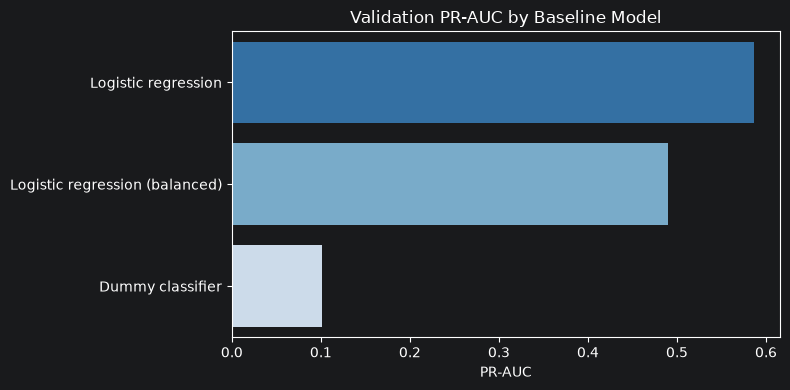

In [8]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=results_df,
    x="pr_auc",
    y="model",
    hue="model",
    legend=False,
    palette="Blues_r",
)

plt.title("Validation PR-AUC by Baseline Model")
plt.xlabel("PR-AUC")
plt.ylabel("")
plt.xlim(left=0)
plt.tight_layout()
plt.show()

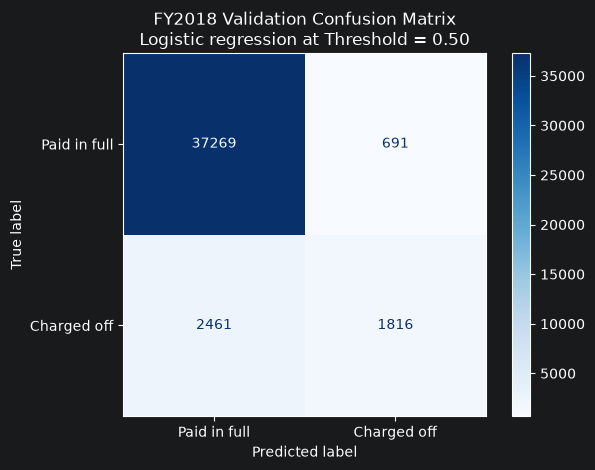

In [9]:
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]

best_probabilities = best_model.predict_proba(X_validation)[:, 1]
best_predictions = (best_probabilities >= 0.50).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_predictions,
    labels=[0, 1],
    display_labels=["Paid in full", "Charged off"],
    cmap="Blues",
)

plt.title(
    f"FY2018 Validation Confusion Matrix\n"
    f"{best_model_name} at Threshold = 0.50"
)
plt.tight_layout()
plt.show()

## Baseline Results

The dummy classifier achieved PR-AUC equal to the validation default rate, confirming that accuracy alone is not meaningful for this imbalanced problem.

Unweighted logistic regression was the strongest baseline model on FY2018 validation data. It achieved the highest PR-AUC and substantially better probability calibration than the class-weighted alternative.

The class-weighted logistic regression produced much higher recall at the default 0.50 threshold, but this came with substantially lower precision, lower PR-AUC, and worse calibration.

The next stage will compare the unweighted logistic-regression benchmark with random forest and XGBoost. After selecting the strongest model family, its decision threshold will be selected on FY2018 by maximizing F1. FY2019 remains untouched until final evaluation.